# STUAART: Continuous Multi-Day Mass Hanging Identification

This Google Colab notebook is designed to identify hanging moments, aka when all scales measure 0g, from the mass data collected by the STUAART system.

Key Features:
- Multi-Day Continuity: Merges data from multiple daily CSV files into a single, linearized timeline.  
- Absolute Clock Alignment: Automatically calculates offsets based on the experiment's start time to view data in cumulative clock time format.  
- Ground Truth Validation: Overlays manual scale measurements directly onto the automated data for accuracy checks.  
- Signal Processing: Includes built-in convolution filters to smooth raw data and highlight underlying trends.  
- Flexible Windows: Supports precise "zooming" into specific hours or days using either relative time or clock-time strings.  

Instructions:
1. Ensure your raw STUAART CSV files are uploaded to your Google Drive.  
2. Update the file paths and experimental parameters in Step 2.  
3. Run all cells to generate individual scale plots and a combined smoothed mass trend.  

Note that you must run your raw data in *Remove buffer flush indicators in raw data.ipynb* before running this Colab. We also encourage removing the baseline shift with *Correct mass time series for baseline shift.ipynb* for better results.

# 1. Setup and Libraries

This cell imports the necessary Python libraries for data manipulation (pandas, numpy), visualization (matplotlib), and file system management.

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.signal import find_peaks
from tqdm import tqdm
from scipy.ndimage import uniform_filter1d, label
from scipy.interpolate import interp1d

# Step 2 : User configuration and Drive mounting

**The user must define these variables :**
1. Paths:
 - Change `project_directory` and `data_path `to point to your data in your Google Drive.

2. Visualisation:
 - `color_scales` : Defines the color of each scale.
 - `save_figure` : If True, figures are saved in a new folder *Figures*.
 - `figure_format` : A string that defines in which format you want your figures to be saved ("eps", "png", etc.)

3. Location identification:
 - `time_window` : Defines range of display. Use *None* to display the full duration, a tuple of numbers for **relative time** (e.g. (0,5)), or a tuple of strings for **absolute clock time** (e.g. ("8:00","12:00")).
 - `bins` : Defines the time (float) to bin the location data. Parameters such as `number_of_entries_per_bin_per_scale`, `average_time_spent_per_bin_per_scale`, `std_time_sent_per_bin_per_scale` and `relative_time_sent_per_bin_per_scale` are computed considering the time bin defined here. For example, 0.5 is 30 minutes.
  - `days` : A list of days to visualise (e.g. [1,2] or ["2026.04.01"]). Note that this variable must be a list even if only one day is selected.

4. Ground truth location (optional):
  - `ground_truth_file` : Defines the path where to find the location indicators per scale done manually by the experimenter. The CSV file should have the first column as the time stamps, and the following columns as an indicator, either 0 or 1, of the presence of the animal on the scale. This is done after, for example, video recording the STUAART to validate the performances of this notebook to identify the animal's location.
  - `delay` : Float. Defines the time delay to match the ground truth labels with the mass time series. If None, the script tries to find the delay by estimating the time frame where there is the best overlap between the ground truth hanging detections and the measurement hanging detections. Otherwise, the delay value is considered.

5. Ground truth mass (optional):
  - `manual_mass` : Add your manual scale measurements here as a list of tuples in the format (day, time, mass). The day can be either integers (e.g. 1) or strings (e.g. "2026.04.01"). The time can either be integers/floats (for relative time) or strings (for absolute clock time in the format "HH:MM")

`debug_mode` : If True, prints more informations for the user.

`save_figures` : If True, saves the figures in a folder called *Figures* in the figure format defined with `figure_format`.

`plot_figures` : If True, plots the figures in addition of printing the location computation parameter values.


After configuring these variables, the next cell will prompt you to mount your Google Drive to grant access to the files.

**Careful** : If `save_figure` is True but `plot_figure` is False, an error will occur.

In [192]:
# Change these variables
project_directory = "/content/drive/My Drive/DCCM_Lab/labdata/vpineaunoel/stuaart"
data_path = project_directory + "/20260730-3MiceInSTUAARTs_5/Pink/WithoutBufferFlushes-BaselineCorrectedAndOutlierRemoval-DBSCANwithManualCorrections/"
color_scales = ["b", "r", "g"]
save_figure = True
save_data = False
save_suffix = "Pink5-20260730-16h30"
debug_mode = False
plot_figures = True
time_acquired_with_millis = False
bins = 0.166666666666 # time to bin the data for location in float. For example, 0.5 is 30 minutes.
time_window = ["15:00", "16:00"] # is either (number, number) for relative time, (str, str) for absolute clock time or None to display all data of the day
days = [1] # is either the day number (starting from 1) of the date in the format "YYYY.MM.DD". Must be a list.
sampling_rate = 80
figure_format = "pdf"
time_when_day_starts_end_ends = [7, 19]

ground_truth_file = project_directory + "/20260730-3MiceInSTUAARTs_5/Pink/HangingGroundTruth/20260730-RecordingPinkFor20min-16h30-DONE-GroundTruthHangingIndicatorPerSecond.csv"
# ground_truth_file = None
delay = -0.9571296

# Add in the list the real mass measurements done during the experiment.
# Format : (day, time, mass)
# manual_mass = [
#     (1, "11:13", 28.8),
#     (2, "11:51", 28.3),
#     (3, "15:41", 27.8),
#     (4, "10:10", 28.5)]
manual_mass = None

In [193]:
from google.colab import drive
drive.mount('/content/drive/')
os.chdir(project_directory)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# 3. File Indexing and Date Extraction

This cell scans the provided data directory and sorts the CSV files. It automatically extracts the acquisition dates and assigns a relative day number (1, 2, 3...) to each file based on the filename prefix (e.g., YYYY.MM.DD-metadata.csv). This indexing allows the script to correctly map your selection in the days variable to the physical files on the drive.

In [194]:
files = os.listdir(data_path)
files.sort()

dates_of_experiment = []
relative_days_of_experiment = []
i = 1
for file in files: # put in order the dates of the experiments based on the beginning of the CSV file names.
  if file.endswith(".csv"):
    index_first_dash = file.find("-")
    dates_of_experiment.append(file[:index_first_dash])
    relative_days_of_experiment.append(i)
    i += 1

if debug_mode:
  print("Dates of experiment : ", dates_of_experiment)
  print("Relative days of experiment : ", relative_days_of_experiment)

# 4. Time Mode Identification

This cell identifies the time mode according to the format of *time_window*.

- If *time_window* are strings (such as ("8:00","12:00")), *clock_time* is True.
- If *time_window* are integers/floats (such as (1.5, 2)), *clock_time* is False.
- If *time_window* is None, *clock_time* is None.

In [195]:
if time_window is None: # no time window selected
  clock_time = False
elif all(isinstance(i, (int, float)) for i in time_window): # relative time
  clock_time = False
elif all(isinstance(i, (str)) for i in time_window): # absolute clock time
  clock_time = True

if debug_mode:
  print("Time window : ", time_window)
  print("Clock time : ", clock_time)

# 5. Linearizing the Time Window and Format Days

To allow for seamless visualization across multiple days, this cell "linearizes" your time selection. If you are using absolute clock time (e.g., from 15:00 on Day 1 to 10:00 on Day 2), the script converts these strings into a continuous float value. It achieves this by (1) converting "HH:MM" strings into decimal hours and (2) adding an offset of 24 hours for every day elapsed since the start of the experiment. For example, "02:00" on Day 2 becomes 26.0 hours ($2 + 24$). This creates a single, continuous timeline, making it possible to zoom into specific periods that span across midnight without breaking the data processing logic.

Additionally, the definition of days depends on the context and is fixed here. If both days and time_window are None, the entire time series across all days is considered. If days is None but time_window is provided, only the first day is considered.

Finally, the script calculates a start_shift based on the first file of the entire experiment (files[0]). This calculation ensures that the clock time remains consistent across all loaded files, allowing the script to correctly map all timestamps to the actual time of day.   

In [196]:
def str_to_float_hour(time_str):
    """Convert str hour in the format 00:00 to a float value"""
    hours, minutes = map(int, time_str.split(':'))
    return hours + (minutes / 60.0)


def format_time_window_and_days(time_window, days, dates_of_experiment, relative_days_of_experiment, start_shift):
  if days is None and time_window is not None: # if no day is specified, but a time window is, the first day is considered
    days = [1]

  elif days is None and time_window is None: # if days and time_window are None, considers all data
    days = relative_days_of_experiment
    time_window = (0, 24)

  elif days is not None and time_window is None: # if time_window is None, all days defined in days are considered
    time_window = (0, 24)

  # Access first and last day of days
  start_day = days[0]
  end_day = days[-1]
  if all(isinstance(day, (int, float)) for day in days):
    formatted_start_day = days[0]
    formatted_end_day = days[-1]
  elif all(isinstance(day, str) for day in days):
    formatted_start_day = dates_of_experiment.index(days[0]) + 1
    formatted_end_day = dates_of_experiment.index(days[-1]) + 1
  else:
    raise ErrorValue("Days is not ints or strings. Verify the definition of days in cell 2.")

  if all(isinstance(time, (int, float)) for time in time_window):
    start_time_in_float = time_window[0] + start_shift
    end_time_in_float = time_window[1] + start_shift
  elif all(isinstance(time, str) for time in time_window):
    start_time_in_float = str_to_float_hour(time_window[0])
    end_time_in_float = str_to_float_hour(time_window[1])

  new_start_time = start_time_in_float + ((formatted_start_day-1) * 24)
  new_end_time = end_time_in_float + ((formatted_end_day-1) * 24)

  if debug_mode:
    print("Start time : ", start_time_in_float)
    print("End time : ", end_time_in_float)
    print("Formatted start day : ", formatted_start_day)
    print("Formatted end day : ", formatted_end_day)
    print("Time window after formatting : ", (new_start_time, new_end_time))
    print("Selected days : ", days)

  return days, (new_start_time, new_end_time)


def format_day_times(time_when_night_start_and_end, days, time_window):
  formatted_day_times = []
  for day in days:
    formatted_day_times.append((time_when_night_start_and_end[0] + ((day-1) * 24), time_when_night_start_and_end[1] + ((day-1) * 24)))
  return formatted_day_times

# compute start shift according to the time the experiment started on the first day
if time_acquired_with_millis:
  absolute_first_file = data_path + files[0]
  first_data = pd.read_csv(absolute_first_file)
  first_duration = first_data.iloc[-1, 0] / (1000 * 60 * 60)
  start_shift = (24.0 - first_duration) % 24
else:
  start_shift = 0

if debug_mode:
  print("Start shift : ", start_shift)

days, time_window = format_time_window_and_days(time_window=time_window, days=days, dates_of_experiment=dates_of_experiment, relative_days_of_experiment=relative_days_of_experiment, start_shift=start_shift)
day_times_per_day = format_day_times(time_when_night_start_and_end=time_when_day_starts_end_ends, days=days, time_window=time_window)

# 6. Data Loading and Global Alignment

This cell performs the core data aggregation and temporal alignment required for multi-day analysis.

1. Global Clock Alignment: The previously computed start_shift is used to align the time to the absolute clock time.   
2. Data Accumulation Loop: It iterates through your selected days, identifying the correct file paths whether you provided day numbers or specific dates. It then extracts the raw millisecond data, converts it into decimal hours, and applies the global shift to the dataset of each day.  
3. Merging and Filtering: All selected data points are merged into two primary arrays: *time_hour* and *mass_data*. Finally, the script uses a boolean mask to filter these arrays, retaining only the measurements that fall precisely within your defined *time_window*. This process enables the seamless visualization of a continuous timeline, even when the data spans across multiple files.

In [197]:
all_time_hour = []
all_mass_data = []

if len(days) > 1:
  all_days = range(days[0], days[-1]+1, 1)
else:
  all_days = days

for d in all_days:
  if type(d) == str:
      actual_day_index = dates_of_experiment.index(d) # ex: 0, 1, 2...
      current_data_path = data_path + files[actual_day_index]
  else:
      actual_day_index = d - 1
      current_data_path = data_path + files[actual_day_index]

  if debug_mode:
    print("Data path : ", current_data_path)
  data = np.array(pd.read_csv(current_data_path))
  time = data[:,0]

  if time_acquired_with_millis:
    current_time_hour = time/(1000 * 60 * 60)
    current_time_hour = (start_shift + current_time_hour)
  else:
    current_time_hour = time

  current_mass_data = data[:, 1:]

  all_time_hour.append(current_time_hour)
  all_mass_data.append(current_mass_data)

print("All time hour : ", all_time_hour, len(all_time_hour), all_time_hour[0].shape)
# all data is contained in time_hour and mass_data after these two lines
time_hour = np.concatenate(all_time_hour)
mass_data = np.concatenate(all_mass_data, axis=0)

if time_acquired_with_millis is False:
  diffs = np.diff(time_hour)
  rollover_next_day = diffs < -12.0
  rollovers = np.concatenate(([False], rollover_next_day))
  days_passed = np.cumsum(rollovers)
  print("rollovers : ", rollovers, rollovers.shape, np.unique(rollovers))
  if 1.0 in all_days and np.any(rollovers):
    time_hour = time_hour + (days_passed * 24.0)
  elif not np.any(rollovers):
    time_hour = time_hour + ((d-1) * 24.0)
  else:
    indices_to_remove = np.where(days_passed == 0)[0]
    mass_data = np.delete(mass_data, indices_to_remove, axis=0)
    time_hour = np.delete(time_hour, indices_to_remove)
    time_hour = time_hour + ((d-1) * 24.0)

print(f"Beginning {time_hour[0]:.3f} and end {time_hour[-1]:.3f} value of time overall.")

mask = (time_hour >= time_window[0]) & (time_hour <= time_window[1])
time_in_window_hour = time_hour[mask]
mass_data_in_window = mass_data[mask, :]

# Initialize a mask of all True (assume everything is night)
is_night = np.ones(len(time_in_window_hour), dtype=bool)
for day_start, day_end in day_times_per_day:
    is_day = (time_in_window_hour >= day_start) & (time_in_window_hour <= day_end)
    is_night[is_day] = False
night_indicator_list = is_night.astype(int)

if debug_mode:
    print("Time window input : ", time_window)
    if len(time_hour) > 0:
      print(f"Time window in absolute clock time : Start {time_in_window_hour[0]:.3f} and End {time_in_window_hour[-1]:.3f}")
    else:
      print("No data found in mask")

    print("Time_hour : ", time_hour, time_hour.shape)
    print(f"Time_hour_in_window : {time_in_window_hour}{time_in_window_hour.shape}")
    print("Mass_data : ", mass_data_in_window, mass_data_in_window.shape)
    print("Night indicator list : ", np.unique(night_indicator_list), night_indicator_list.shape)

All time hour :  [array([13.08698722, 13.08698944, 13.08699222, ..., 23.99996528,
       23.99996722, 23.99997056])] 1 (3355503,)
rollovers :  [False False False ... False False False] (3355503,) [False]
Beginning 13.087 and end 24.000 value of time overall.


# 7. Processing and Filtering Manual Measurements (Ground Truth)

This cell handles the manual scale measurements (ground truth) provided by the user, ensuring they are correctly positioned on the continuous multi-day timeline.

1. Time Linearization (*format_manual_mass()*): Just as the raw data was shifted to create a continuous timeline, this function converts the *manual_mass* tuples into linearized values. It identifies the correct day of the experiment and adds a 24-hour offset for each elapsed day. This ensures that a manual weighing at 10:00 AM on Day 2 is accurately mapped to Hour 34.0 on the graph.  
2. Window Filtering (*filter_manual_measurements()*): This function sifts through the linearized manual measurements and retains only those that fall within your *time_window*.  

Output: The resulting *real_mass* variable contains the specific data points that will be overlaid on the final plot for visual validation of the STUAART accuracy to track the mass.

In [198]:
def filter_manual_measurements(measurements, current_days, dates_of_experiment, current_window, is_clock_mode):
  filtered_times = []
  filtered_masses = []

  for m_time, m_mass in measurements:
    # convert time in float
    if isinstance(m_time, str):
      t_float = str_to_float_hour(m_time) # function defined in that last cell
    else:
      t_float = m_time # relative time is kept as is

    # check time
    if current_window is not None:
      w_start = str_to_float_hour(current_window[0]) if isinstance(current_window[0], str) else current_window[0]
      w_end = str_to_float_hour(current_window[1]) if isinstance(current_window[1], str) else current_window[1]

    if not (w_start <= t_float <= w_end):
      continue

    filtered_times.append(t_float)
    filtered_masses.append(m_mass)

  return filtered_times, filtered_masses


def format_manual_mass(manual_mass, dates_of_experiment, relative_days_of_experiment, start_shift):
  if manual_mass is None:
    return None
  else:
    new_manual_mass = []
    for m_day, m_time, m_mass in manual_mass:
      if isinstance(m_day, (int, float)):
        new_day = relative_days_of_experiment[m_day-1]
      elif isinstance(m_day, str):
        new_day = dates_of_experiment.index(m_day) + 1

      if isinstance(m_time, str):
        time_in_float = str_to_float_hour(m_time)
      else:
        time_in_float = m_time + start_shift

      new_time = time_in_float + ((new_day-1) * 24)
      new_manual_mass.append((new_time, m_mass))

  return new_manual_mass


if manual_mass is not None:
  if debug_mode:
    print("Manual mass as input : ", manual_mass)
    print("Type of manual mass : ", type(manual_mass))
    print("Current days : ", days)
    print("Current time window : ", time_window, type(time_window))

  new_manual_mass = format_manual_mass(manual_mass=manual_mass, dates_of_experiment=dates_of_experiment, relative_days_of_experiment=relative_days_of_experiment, start_shift=start_shift)
  real_mass = filter_manual_measurements(measurements=new_manual_mass, current_days=days, dates_of_experiment=dates_of_experiment, current_window=time_window, is_clock_mode=clock_time)

  if debug_mode:
    print("Real mass after formatting : ", new_manual_mass)
    print("Real mass after filtering with time_window : ", real_mass)

else:
  real_mass = None

# 8. Total Mass Computation

This cell calculates the total mass of the entire STUAART. `sum_data_over_time()` sums the values from all scales at each timestamp to provide a single total cage mass measurement.  

In [199]:
def sum_data_over_time(data_per_scale):
  """
  Sum data per time point to obtain the mass measurement over time of the whole cage system (and not only per scale).
  """
  summed_data = np.nansum(data_per_scale, axis=1)
  return summed_data

summed_data_in_window = sum_data_over_time(data_per_scale=mass_data_in_window)

if debug_mode:
  print("Shape of mass data before summing mass over every timestamp: ", mass_data_in_window.shape)
  print("Shape of summed data : ", summed_data_in_window.shape)
  print("Shape of time : ", time_in_window_hour.shape)

## 9. Hanging Detection
This cell processes the mass time series to detect and quantify hanging behavior.

`when_mouse_is_in()`: Detects the exact timestamp the mouse is introduced to the cage by finding the first sustained deviation from the 0g baseline.

`convolution_filter_with_padding_edge()`: Applies either a moving average (for smoothing) or a custom high-pass filter to the mass data. It uses mean padding to prevent unwanted boundary artifacts at the edges of the arrays.

`compute_hanging()`: (1) Runs your average filter to clean up the baseline noise, (2) flags every single data point where the smoothed mass drops below your threshold (< 5g), (3) It groups those flagged points into independent blocks (using scipy.ndimage.label) based on when the mass drops down and when it genuinely climbs back up and (4) checks the literal duration of each independent block, keeping only the ones that last between 1 second and 3 minutes. Everything else is discarded.

In [200]:
def when_mouse_is_in(time, data, sampling_rate):
  """
  Identifies the moment when the mouse is in the cage.
  Data acquisition starts with a plateau at 0g. When the mouse is in, the mean mass goes up.
  Creates two class variables with the time and the mass data when the mouse is in.
  """
  length = sampling_rate
  for i in range(data.shape[0]):
    mean = np.mean(data[i: i+length])
    if np.isclose(mean, 0, atol=3): # + or - one gram is still considered at 0g.
      i += length
    else:
      break
  time_when_mouse_is_in = time[i+length]

  return time_when_mouse_is_in


def convolution_filter_with_padding_edge(data, length: int=10, iteration: int=1, kernel_type: str="average"):
  """ High-pass convolution filter on the signal. This filter is meant to smooth up the signal
  and remove outliers without any threshold. The edges are padded to correct for boundary effects.
  Arguments:
  - length: length of the kernel to convolve on signal. default is 10
  - iteration: number of consecutive convolutions to do. default is 1
  - kernel_type : either average or high-pass
  """
  # raise an error if number of iteration is not possible
  if iteration <= 0:
    raise ValueError("Number of iteration cannot be under 1")

  input_data_length = data.shape[0]
  current_data = data.copy()

  if kernel_type == 'average':
    for _ in range(iteration):
      valid_mask = ~np.isnan(current_data)
      data_filled = np.nan_to_num(current_data, nan=0.0)

      # Vectorized across all scales at once using axis=0
      moving_sum = (uniform_filter1d(data_filled, size=length, axis=0, mode='nearest') * length)
      moving_count = (uniform_filter1d(valid_mask.astype(float), size=length, axis=0, mode='nearest') * length)

      with np.errstate(divide='ignore', invalid='ignore'):
        current_data = moving_sum / moving_count
        current_data[moving_count == 0] = np.nan

    return current_data

  elif kernel_type == "high-pass" :
    filtering_array = np.array([-1, -1, 0, 0, 0, 0, 0, 1, 1])  # High-pass filter
    pad_width = len(filtering_array) // 2  # Automatically 4
    current_data = data.copy()

    for i in range(iteration):
      # Pad current_data (not original data) using mean mode
      padded_data = np.pad(current_data, pad_width, mode='mean')
      convolved_data = np.convolve(padded_data, filtering_array, mode='same')

      # Slice back using pad_width to match kernel size precisely
      current_data = convolved_data[pad_width : pad_width + input_data_length]

    return current_data

    return resized_convolved_data


def compute_hanging(time, summed_data, sampling_rate: int, threshold: int = 5, bins: float = 0.5, first_day: bool = False):
  """
  Hanging is when the mass data drops below the threshold for more than 1 second.
  A convolution is done with an average filter to smooth the data.
  Contiguous blocks below the threshold are identified using region labeling.
  Calculates hanging moments, total time hanging per bin, and hanging frequency per bin.
  """
  # Smooth the data using the average filter
  avg_conv_data = convolution_filter_with_padding_edge(data=summed_data, length=15, kernel_type="average")

  # Direct threshold masking: find all points where smoothed mass drops below threshold
  is_low_mass = (avg_conv_data < threshold)

  # Label contiguous blocks of low mass (connected components)
  labeled_array, num_features = label(is_low_mass)

  start_indices = []
  end_indices = []
  hanging_moments = np.zeros(shape=time.shape)

  # Time conversion constants (since 'time' is in decimal hours)
  min_duration_hours = 1.0 / 3600.0        # 1 second in hours
  max_duration_hours = 180.0 / 3600.0      # 3 minutes in hours

  for region_id in range(1, num_features + 1):
    indices = np.where(labeled_array == region_id)[0]
    if len(indices) == 0:
      continue

    start = indices[0]
    end = indices[-1]
    duration = time[end] - time[start]

    # Filter by physical duration limits (1 second to 3 minutes)
    if min_duration_hours <= duration <= max_duration_hours:
      start_indices.append(start)
      end_indices.append(end)
      hanging_moments[start:end + 1] = 1  # end + 1 to include the endpoint

  start_indices = np.array(start_indices)
  end_indices = np.array(end_indices)

  # Handle first day exclusion
  if first_day and len(start_indices) > 0:
    time_when_mouse_is_in = when_mouse_is_in(time=time, data=summed_data, sampling_rate=sampling_rate)
    index_when_mouse_is_in = np.argmin(np.abs(time - time_when_mouse_is_in))
    valid_mask = start_indices >= index_when_mouse_is_in
    start_indices = start_indices[valid_mask]
    end_indices = end_indices[valid_mask]
    hanging_moments[:index_when_mouse_is_in] = 0

  # Get start and end times of validated bouts
  start_hanging = time[start_indices] if len(start_indices) > 0 else np.array([])
  end_hanging = time[end_indices] if len(end_indices) > 0 else np.array([])

  # Define bin edges consistently
  bin_edges = np.arange(time[0], time[-1] + bins, bins)

  hanging_frequency = []
  hanging_time_per_bin = []

  # Integrate overlap of each bout with each time bin window [bin_start, bin_end)
  for bin_start, bin_end in zip(bin_edges[:-1], bin_edges[1:]):
    if len(start_hanging) == 0:
      hanging_frequency.append(0)
      hanging_time_per_bin.append(0.0)
      continue

    # Count bouts whose start time falls inside the bin
    bouts_started = np.count_nonzero((start_hanging >= bin_start) & (start_hanging < bin_end))
    hanging_frequency.append(bouts_started)

    # Compute duration overlap for bouts spanning or falling within this bin
    # Overlap = max(0, min(bout_end, bin_end) - max(bout_start, bin_start))
    overlap_starts = np.maximum(start_hanging, bin_start)
    overlap_ends = np.minimum(end_hanging, bin_end)
    overlaps = np.maximum(0.0, overlap_ends - overlap_starts)

    total_bin_time = float(np.sum(overlaps))
    hanging_time_per_bin.append(total_bin_time)

  hanging_frequency = np.array(hanging_frequency)
  hanging_time_per_bin = np.array(hanging_time_per_bin)

  return hanging_moments, hanging_time_per_bin, hanging_frequency



if relative_days_of_experiment[0] == days[0]:
  first_day = True
else:
  first_day = False

hanging_moments, total_time_hanging, hanging_frequency = compute_hanging(time=time_in_window_hour, summed_data=summed_data_in_window, first_day=first_day, threshold=5, sampling_rate=sampling_rate, bins=bins)

if debug_mode:
  print(f"Hanging moments : {hanging_moments} {hanging_moments.shape}")
  print(f"Total time hanging in selected time window : {total_time_hanging} hour(s)")
  print(f"Hanging frequency per bin : {hanging_frequency} {hanging_frequency.shape}")
  print(f"Bins : {bins}")

# 10. Format ground truth labels (optional)

This section automates the temporal alignment between high-resolution experimental data and reference ground-truth data. If `ground_truth_data` is `None`, this section is skipped.

`find_optimal_time_delay()` : Finds the time delay by scanning a range of candidate delays and maximizing the overlap of presence states (`1`s) between the automated detections and the ground truth detections.

In [201]:
def find_optimal_time_delay(high_res_array, high_res_time, low_res_array, low_res_time, search_range_hours=(-1.0, 1.0), step_seconds=1.0,):
  """
  Finds the true time delay by scanning a range of candidate delays
  and maximizing the overlap of presence (1s). Supports both 1D and 2D arrays.
  """
  dt_hours = step_seconds / 3600.0
  delays = np.arange(search_range_hours[0], search_range_hours[1] + dt_hours, dt_hours)

  f_base = interp1d(low_res_time,low_res_array,kind='nearest',bounds_error=False,fill_value=0,)
  best_delay = 0
  max_overlap = -1

  for tau in delays:
    y_candidate = f_base(high_res_time - tau)
    overlap = np.sum((high_res_array == 1) & (y_candidate == 1))

    if overlap > max_overlap:
      max_overlap = overlap
      best_delay = tau

  return best_delay

if ground_truth_file is not None:
  df_ground_truth_data = pd.read_csv(ground_truth_file, index_col=0)
  time_ground_truth = np.array(df_ground_truth_data.iloc[:, 0])
  cumulative_time_ground_truth = time_ground_truth+((days[0]-1)*24)
  indicators_per_scale_ground_truth = df_ground_truth_data.iloc[:, 1:]
  indicators_per_scale_ground_truth = np.array(indicators_per_scale_ground_truth).T

  if delay is None:
    all_dts = []
    for i in range(indicators_per_scale_ground_truth.shape[0]):
      dt = find_optimal_time_delay(
          high_res_array=hanging_moments[:,i],
          high_res_time=time_in_window_hour,
          low_res_array=indicators_per_scale_ground_truth[i],
          low_res_time=cumulative_time_ground_truth
          )
      all_dts.append(dt)
    dt = np.mean(all_dts)
  else:
    dt = delay
  if debug_mode:
    print("Time delay for optimal overlap : ", dt)
  ground_truth_data = (cumulative_time_ground_truth + dt, indicators_per_scale_ground_truth[0])
else:
  ground_truth_data = None

if debug_mode:
  if ground_truth_file is None:
    pass
  else:
    print("Ground truth data time : ", ground_truth_data[0].shape)
    print("Ground truth data indicators per scale : ", ground_truth_data[1], ground_truth_data[1].shape, np.unique(ground_truth_data[1]))

## 11. Data Smoothing and Hanging Moments Visualization

If `plots_figures` is True, this cell displays the summed mass data from each timestamp with the smoothened mass and the identified hanging moments for visualization. Otherwise, this cell does nothing.


`convolution_filter_with_padding_edge_average()`: It is hardcoded to perform a moving average (smoothing) with edge padding to prevent boundary distortion.

`remove_values_under_threshold()`: It filters out mass readings below a specific threshold (e.g., 5g or 10g).

`compute_mean_data()`: Extracts the long-term trend of the mouse's mass. It first cleans the data by dropping all values under 10g, then applies a massive moving average (kernel length of 10,000) over multiple iterations. This flattens out micro-fluctuations to reveal the true biological mass trajectory.

`plot_raw_mass_time_series_with_hanging_indicator()`: It builds a multi-layered plot containing (1) the summed raw mass, (2) the smoothened mass to look at the weight trends, (3) the hanging moments, which are displayed as vertical color bars highlighting when the hanging behaviours occur, (4) the real mass validation, if `real_mass` is not None, with yellow stars and (5) when the lights are turned off, aka night time, with light gray background.

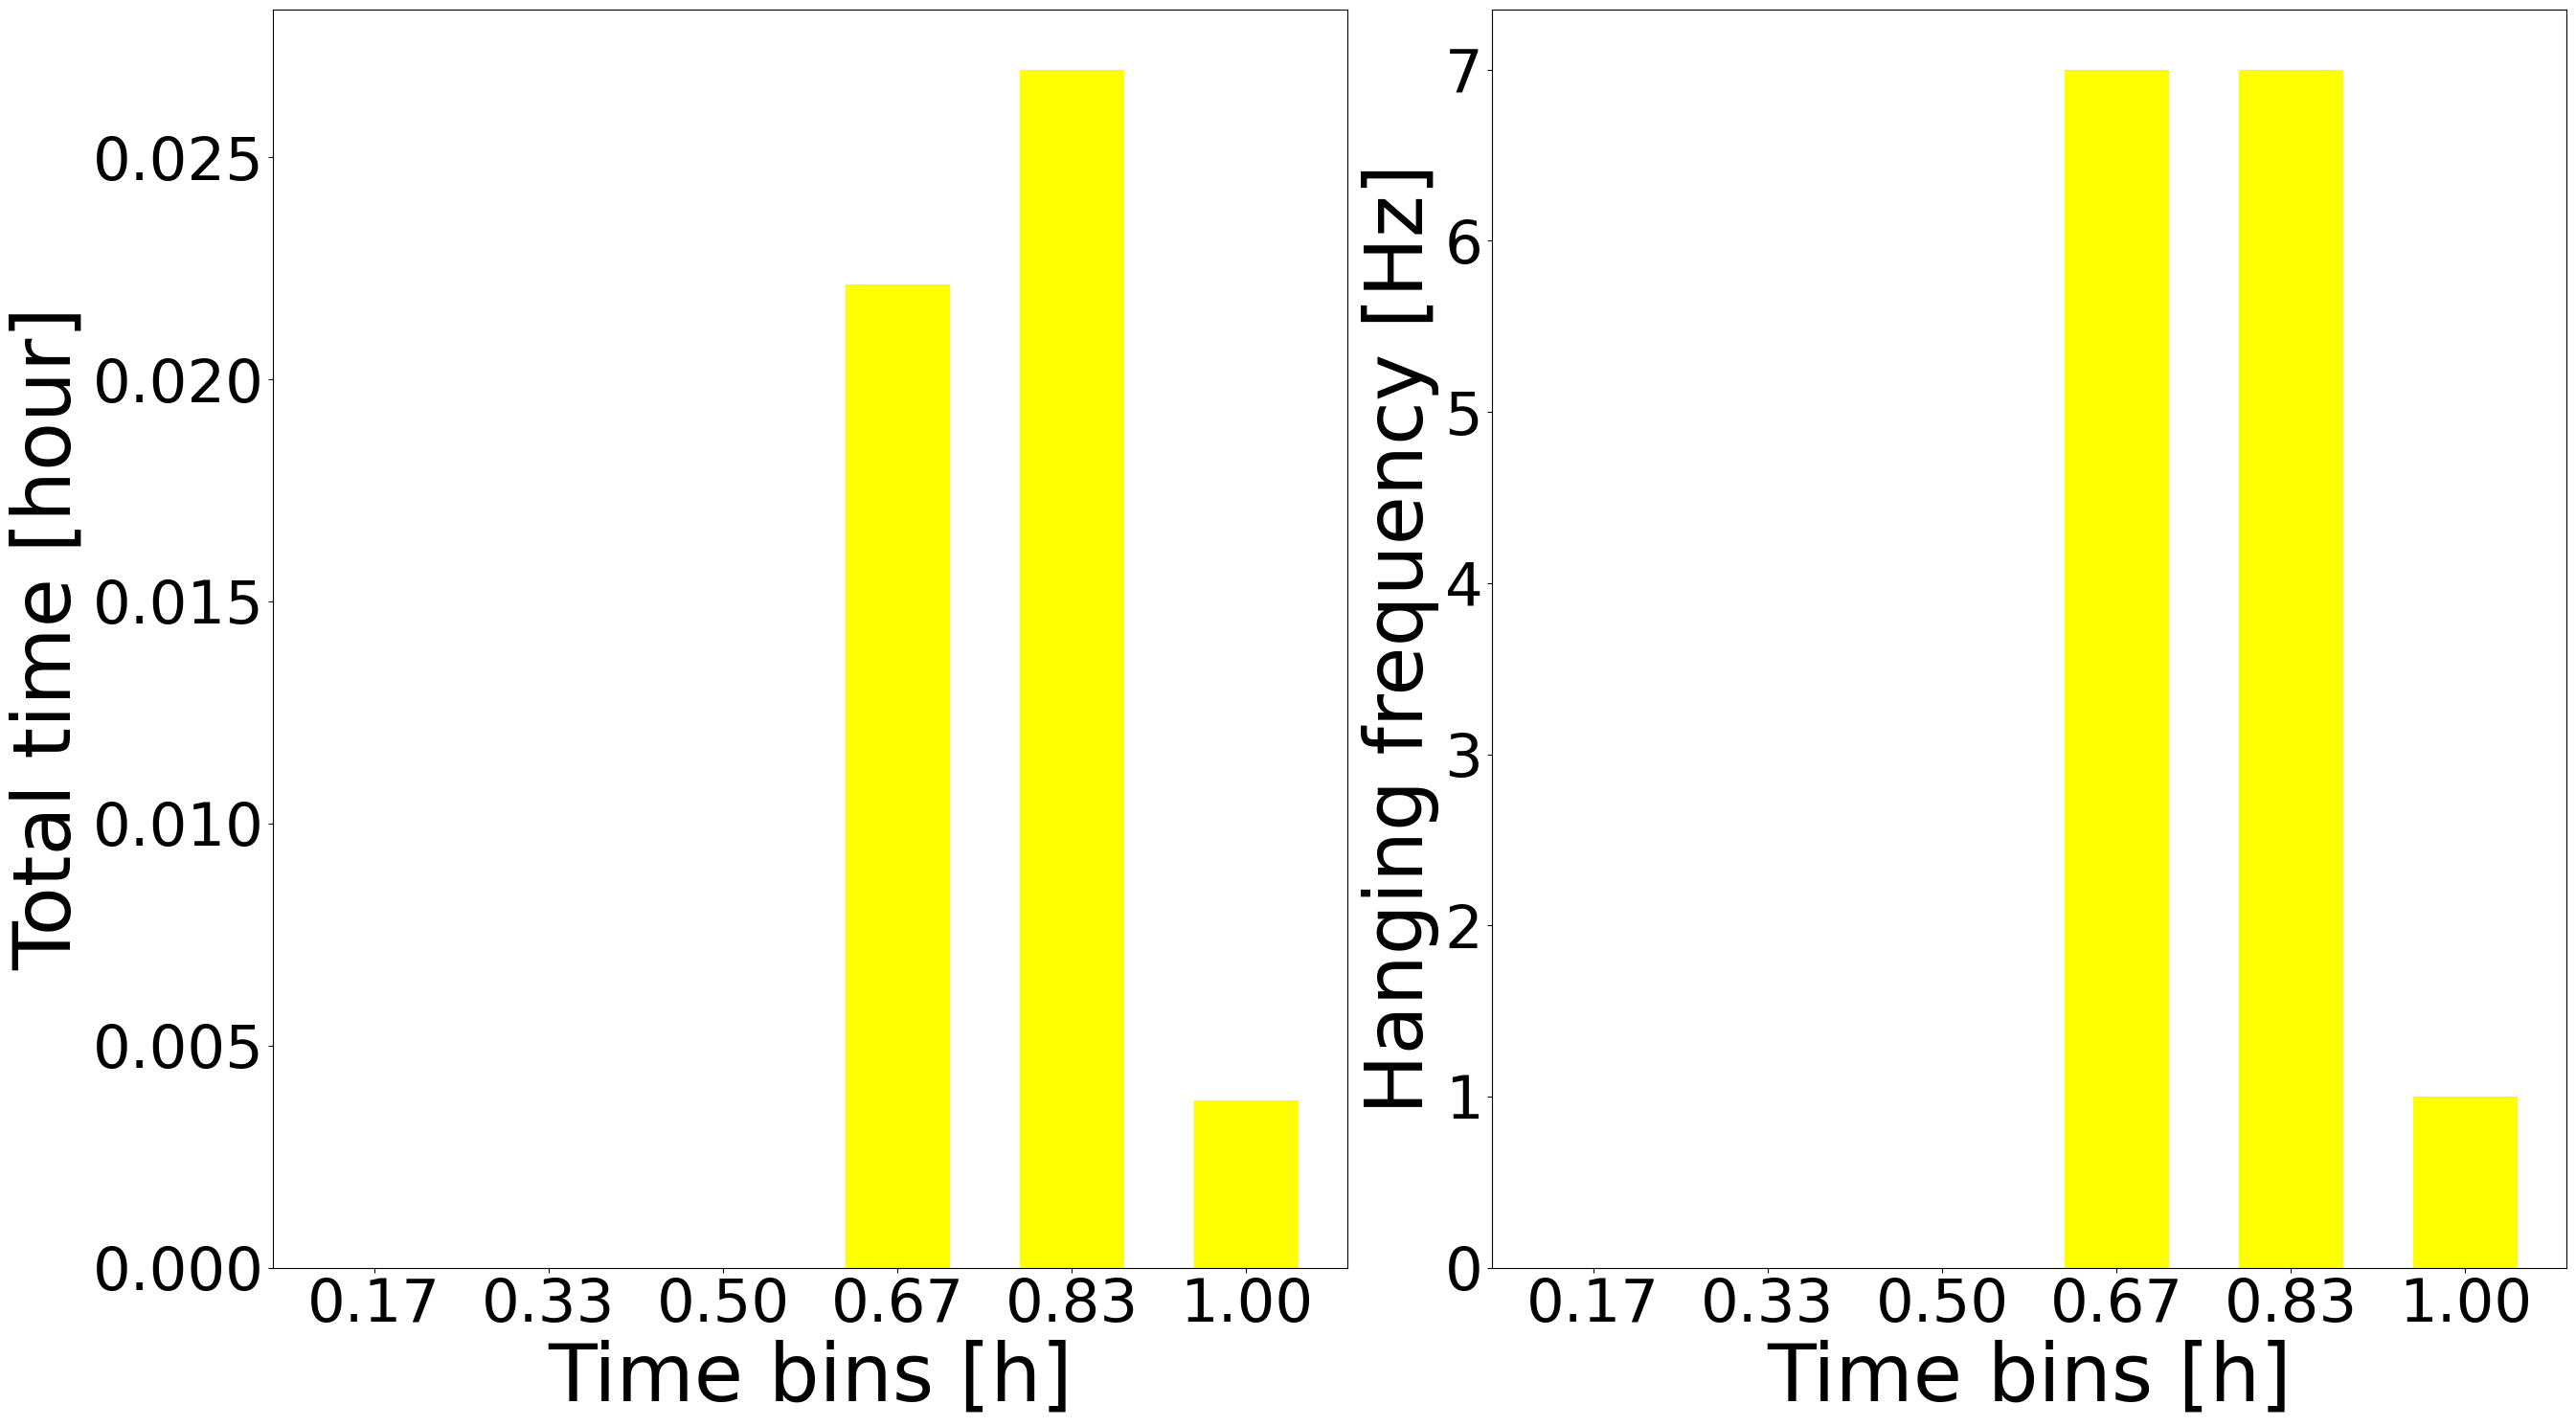

In [202]:
def convolution_filter_with_padding_edge_average(data, length: int=10, iteration: int=1):
  """ Convolution filter on the signal. This filter is meant to smooth up the signal
  and remove outliers without any threshold. The edges are padded to correct for boundary effects.

  Arguments:
  - length: length of the kernel to convolve on signal. default is 10
  - iteration: number of consecutive convolutions to do. default is 1
  """
  # raise an error if number of iteration is not possible
  if iteration <= 0:
    raise ValueError("Number of iteration cannot be under 1")

  input_data_length = data.shape[0]
  # create an array of approriate length of 1/length at every position
  # this is the specific case of moving average
  filtering_array = np.ones(length)/length
  # doing the convolution the specified number of times
  for i in range(iteration):
    # 'same' arg is used to get an array of same size as self.data. Boundary effects are corrected with edge padding. The extra data on the edges are removed after the convolution with slicing.
    pad_width = len(filtering_array) // 2
    padded_data = np.pad(data, pad_width, mode='mean')
    convolved_data = np.convolve(padded_data, filtering_array, mode='same')
    resized_convolved_data = convolved_data[int(length/2):int(length/2+input_data_length)]

  return resized_convolved_data


def remove_values_under_threshold(time, data, threshold: float=5):
  """
  Remove every data points under a specified threshold

  Arguments:
  - threshold: specified threshold. default is 5.
  """
  # get all index where condition is met
  # squeeze() ensures that index array is one-dimensional
  positive_values_index = np.argwhere(data >= threshold).squeeze()
  # keep only data_points where condition is met
  new_data = data[positive_values_index]
  new_time = time[positive_values_index]

  return new_time, new_data


def compute_mean_data(time, summed_data, smooth_level: int=3):
  """
  Computes the mean of the mass to smoothen it maximally and only see the tendency of the mass change over time.
  First removes all data points under 10 g.
  Then convolves the data using 600 points.

  smooth_level : The higher, the smoother. Actively, it changes the number of iterations of convolution.
  """
  clean_time, clean_data = remove_values_under_threshold(time=time, data=summed_data, threshold=10)
  convolved_data = convolution_filter_with_padding_edge_average(data=clean_data, length=10000, iteration=smooth_level)
  return clean_time, convolved_data


def plot_raw_mass_time_series_with_hanging_indicator(time, data, hanging_moments, is_saved, colors, real_mass, clock_time, time_window, figure_format, night_indicator_list, ground_truth_data=None):
  """
  The summed mass over every timestamp is displayed as well as the smoothened data over time, done with a moving average, and the hanging moments.
  """
  convolved_time, convolved_data = compute_mean_data(time=time, summed_data=data, smooth_level=10)

  if debug_mode:
    print("Time before moving average : ", time, time.shape)
    print("Time after moving average : ", convolved_time, convolved_time.shape)
    print("Data before moving average : ", data, data.shape)
    print("Data after moving average : ", convolved_data, convolved_data.shape)
    print(f"Hanging moments : {hanging_moments} of shape {hanging_moments.shape} with unique values of {np.unique(hanging_moments)}.")

  fig, axs = plt.subplots(1, 1, figsize=(20,10))

  plt.plot(time, data, color="black", linewidth=4, alpha=0.6, label="Raw mass", zorder=3)
  plt.plot(convolved_time, convolved_data, color="black", linewidth=4, label="Smoothened mass", zorder=4)
  plt.fill_between(time, np.amax(data), where=hanging_moments == 1, color="yellow", alpha=0.5, zorder=2)
  if real_mass is not None:
    plt.scatter(real_mass[0], real_mass[1], marker="*", edgecolors="k", color="y", label="Real mass", s=1000, zorder=5)
  if ground_truth_data is not None:
    plt.fill_between(ground_truth_data[0], np.nanmax(convolved_data)+10, where=ground_truth_data[1] == 1, color='red', alpha=0.4, label="Ground truth hanging labels", zorder=1)


  plt.xlabel("Cumulative time of day [h]", fontsize=50)
  plt.ylabel("Mass [g]", fontsize=50)
  plt.tick_params(axis='both', which='major', labelsize=35)

  # nights have a lightgray background
  ax = plt.gca()
  plt.fill_between(time_in_window_hour, 0, 1, where=is_night, color='lightgray', alpha=1, transform=ax.get_xaxis_transform(), label="Night", zorder=1)

  # plt.legend(loc="upper right")

  if is_saved:
    path = Path(data_path)
    figure_path = path.parent / "Figures"
    figure_path.mkdir(parents=True, exist_ok=True)
    file_stem = path.stem
    if time_window is None:
      suffix = "-SumData-Hanging-Raw." + figure_format
    else:
      suffix = f"-SumData-Hanging-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours-Raw." + figure_format

    save_path = figure_path / (file_stem + suffix)
    fig.tight_layout()
    plt.savefig(save_path, format=figure_format, transparent=True, facecolor='white', edgecolor='none')
  plt.show()


def plot_activity_per_day(total_time_hanging, hanging_frequency, is_saved=False, figure_format="png", bins:float=0.5):
  num_bins = hanging_frequency.shape[0]

  factor = 3

  fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(9*factor,5*factor))
  x = np.arange(num_bins)
  total_group_width = 0.6
  bar_width = total_group_width

  axs[0].bar(x, total_time_hanging, color="yellow", width=bar_width)
  axs[1].bar(x, hanging_frequency, color="yellow", width=bar_width)

  axs[0].set_ylabel("Total time [hour]", fontsize=20*factor)
  axs[1].set_ylabel("Hanging frequency [Hz]", fontsize=20*factor)
  axs[0].set_xlabel("Time bins [h]", fontsize=20*factor)
  axs[1].set_xlabel("Time bins [h]", fontsize=20*factor)

  real_time_labels = (bins) + bins * np.arange(num_bins)

  for ax in axs:
    ax.set_ylim(bottom=0)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{val:.2f}" for val in real_time_labels], fontsize=15*factor)
    ax.tick_params(axis='y', labelsize=15*factor)
  fig.tight_layout()

  if is_saved:
    path = Path(data_path)
    figure_path = path.parent / "Figures"
    figure_path.mkdir(parents=True, exist_ok=True)
    file_stem = path.stem
    if time_window is None:
      suffix = "-TotalHangingTime-HangingFrequency-PerBin." + figure_format
    else:
      suffix = f"-TotalHangingTime-HangingFrequency-PerBin-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours-Raw." + figure_format

    save_path = figure_path / (file_stem + suffix)
    fig.tight_layout()
    if figure_format == "png":
      plt.savefig(save_path, format=figure_format, dpi=600, transparent=True, facecolor='white', edgecolor='none')
    else:
      plt.savefig(save_path, format=figure_format, transparent=True, facecolor='white', edgecolor='none')
  plt.show()


if plot_figures:
  if ground_truth_data is None:
    plot_raw_mass_time_series_with_hanging_indicator(time=time_in_window_hour, data=summed_data_in_window, hanging_moments=hanging_moments, is_saved=save_figure, colors=color_scales, real_mass=real_mass, clock_time=clock_time, time_window=time_window, figure_format=figure_format, night_indicator_list=night_indicator_list)
  else:
    plot_raw_mass_time_series_with_hanging_indicator(ground_truth_data=ground_truth_data, time=time_in_window_hour, data=summed_data_in_window, hanging_moments=hanging_moments, is_saved=save_figure, colors=color_scales, real_mass=real_mass, clock_time=clock_time, time_window=time_window, figure_format=figure_format, night_indicator_list=night_indicator_list)
  plot_activity_per_day(total_time_hanging=total_time_hanging, hanging_frequency=hanging_frequency, is_saved=save_figure, figure_format=figure_format, bins=bins)

# 12. Save hanging moments indicators

If `save_data` is True, the mass time series in the selected `time_window` at the selected `days` is saved as well as the hanging moment indicators.

In [203]:
if save_data:
  data ={"Time in time window [h]":time_in_window_hour, "Summed mass in time window":summed_data_in_window, "Hanging moments in time window":hanging_moments, "Night indicator":night_indicator_list}
  df = pd.DataFrame(data)
  path = Path(data_path)
  saved_path = path.parent / "Results of Hanging Analysis"
  saved_path.mkdir(parents=True, exist_ok=True)
  file_stem = path.stem
  suffix = save_suffix + "-SummedMass_HangingIndicator_NightIndicator.csv"
  save_path = saved_path / (file_stem + suffix)
  df.to_csv(save_path)